In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report


In [5]:
data = pd.read_csv("dataset/improved_disease_dataset.csv")
data.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)


In [7]:
print(data)

      fever  headache  nausea  vomiting  fatigue  joint_pain  skin_rash  \
0         1         0       1         0        1           0          0   
1         0         0       1         0        0           0          1   
2         0         0       1         0        1           0          1   
3         0         0       1         1        1           0          1   
4         1         0       1         0        1           0          0   
...     ...       ...     ...       ...      ...         ...        ...   
1995      1         1       0         0        1           0          0   
1996      1         0       0         0        1           1          1   
1997      1         0       0         1        0           0          0   
1998      0         0       0         0        1           1          0   
1999      0         0       0         1        1           1          0   

      cough  weight_loss  yellow_eyes                       disease  
0         1            1     

In [8]:
x = data.drop(columns = ["disease"])
y = data["disease"]

In [9]:
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size =0.2, random_state =42, stratify = y)

In [10]:
model = RandomForestClassifier(n_estimators = 300, random_state = 42)
model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [14]:
pred = model.predict(x_test)
acc = accuracy_score(y_test, pred)
print("Symptom Accuracy:", acc)


Symptom Accuracy: 0.35


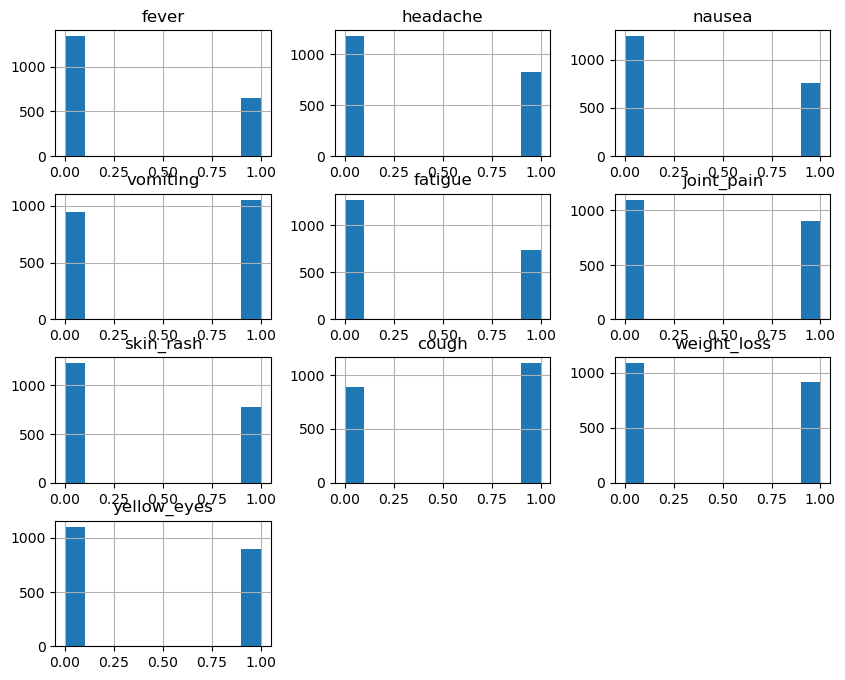

In [24]:
data.hist(figsize=(10,8))
plt.show()

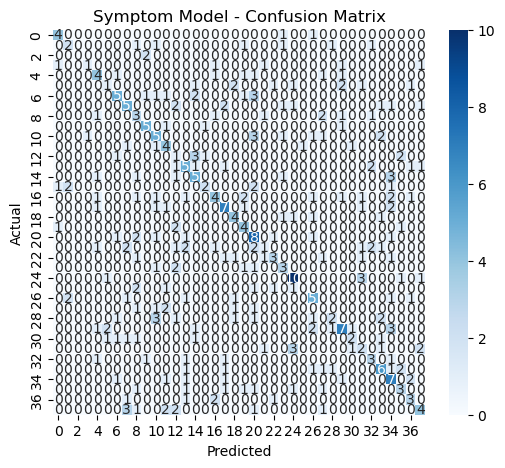

In [15]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Symptom Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

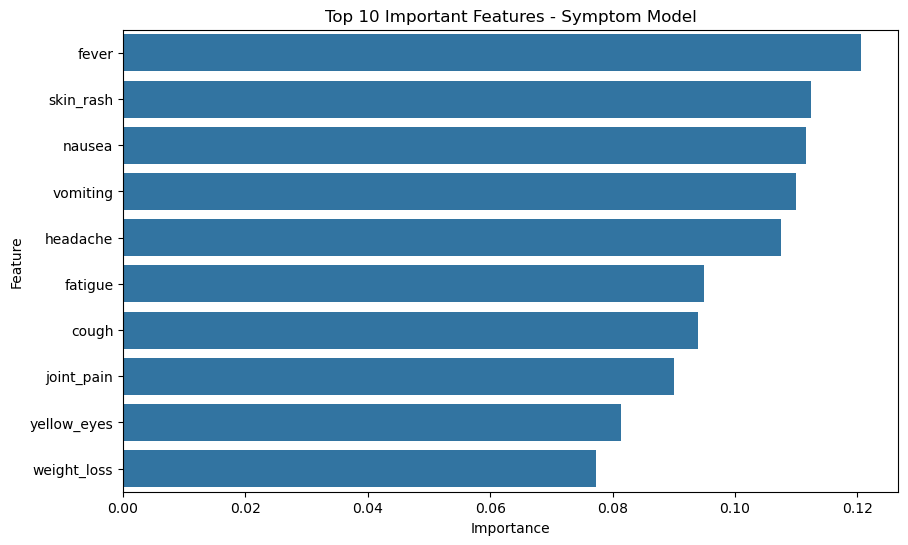

In [17]:
feature_importance = model.feature_importances_
features = x.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Important Features - Symptom Model")
plt.show()

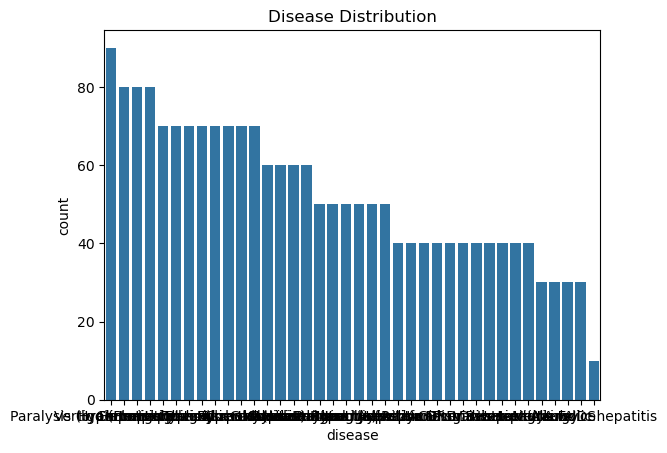

In [18]:
sns.countplot(x=y)
plt.title("Disease Distribution")
plt.show()